Claves encontradas:
dict_keys(['det_W', 'det_b', 'cls_W', 'cls_b', 'history'])

Forma de los pesos:
W_det: (32, 1)
b_det: (1, 1)

Forma de los datos:
X_raw: (20000, 4)
X_windows: (19981, 20, 4)
X_features: (19981, 32)
y_real: (19981,)


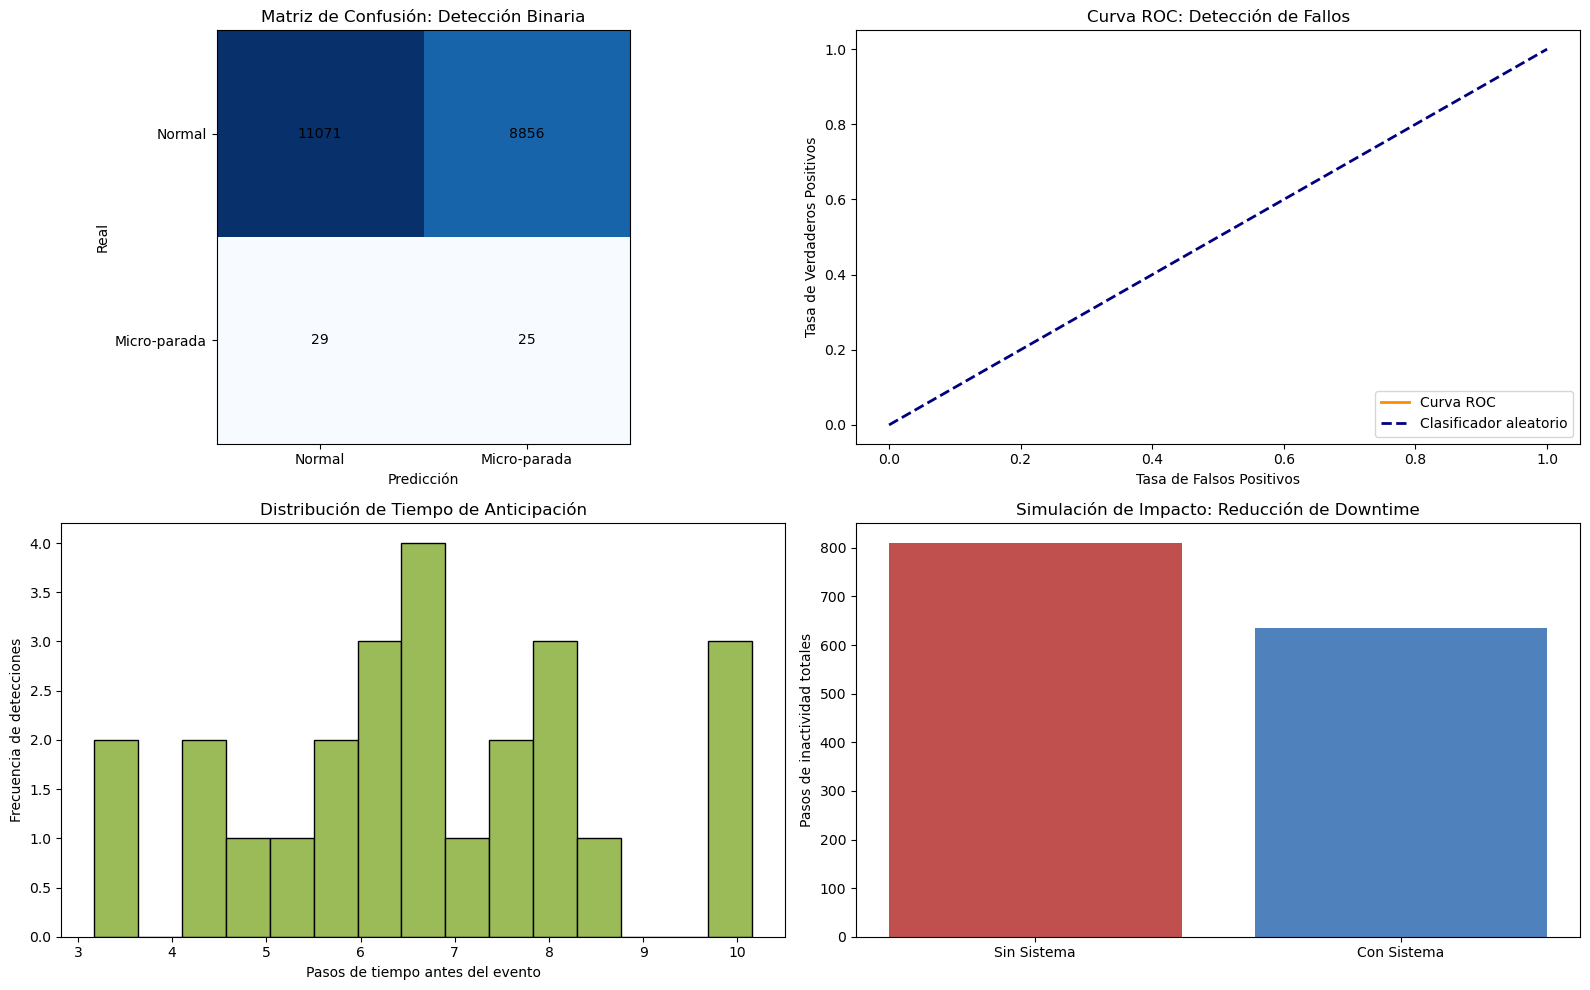


Resultados Finales:
- Accuracy: 0.56
- Precision: 0.00
- Recall: 0.46
- F1-Score: 0.01
- Verdaderos Positivos: 25
- Falsos Positivos: 8856
- Falsos Negativos: 29
- Verdaderos Negativos: 11071
- Ahorro de tiempo total: 175 pasos
- Reducción porcentual: 21.6%


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. CARGA DE DATOS Y PESOS
# ===============================

data = np.genfromtxt('industrial_dataset.csv', delimiter=',', skip_header=1)

X_raw = data[:, :4]
y_real_all = data[:, 4].astype(int)

pesos = np.load('pesos_modelo.npy', allow_pickle=True).item()

print("Claves encontradas:")
print(pesos.keys())

# Cargar pesos que SÍ existen en tu archivo
W_det = pesos['det_W']
b_det = pesos['det_b']

print("\nForma de los pesos:")
print("W_det:", W_det.shape)
print("b_det:", b_det.shape)


# ===============================
# 2. PREPARACIÓN DE VENTANAS
# ===============================

def crear_ventanas(data, window_size=20):
    ventanas = []

    for i in range(len(data) - window_size + 1):
        ventanas.append(data[i:i + window_size])

    return np.array(ventanas)


window_size = 20

X_windows = crear_ventanas(X_raw, window_size)
y_real = y_real_all[window_size - 1:]


# ===============================
# 3. EXTRACCIÓN DE CARACTERÍSTICAS
# ===============================
# Como W_det tiene forma (32, 1), necesitamos crear 32 características.
# Tenemos 4 variables y sacamos 8 características por variable:
# media, desviación, mínimo, máximo, primero, último, rango y tendencia.

def extraer_caracteristicas(ventanas):
    caracteristicas = []

    for ventana in ventanas:
        features = []

        for columna in range(ventana.shape[1]):
            sensor = ventana[:, columna]

            media = np.mean(sensor)
            desviacion = np.std(sensor)
            minimo = np.min(sensor)
            maximo = np.max(sensor)
            primero = sensor[0]
            ultimo = sensor[-1]
            rango = maximo - minimo
            tendencia = ultimo - primero

            features.extend([
                media,
                desviacion,
                minimo,
                maximo,
                primero,
                ultimo,
                rango,
                tendencia
            ])

        caracteristicas.append(features)

    return np.array(caracteristicas)


X_features = extraer_caracteristicas(X_windows)

print("\nForma de los datos:")
print("X_raw:", X_raw.shape)
print("X_windows:", X_windows.shape)
print("X_features:", X_features.shape)
print("y_real:", y_real.shape)

# Validar dimensiones
if X_features.shape[1] != W_det.shape[0]:
    raise ValueError(
        f"Error de dimensiones: X_features tiene {X_features.shape[1]} columnas, "
        f"pero W_det espera {W_det.shape[0]} entradas."
    )


# ===============================
# 4. INFERENCIA
# ===============================

def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))


y_probs = sigmoid(np.dot(X_features, W_det) + b_det).flatten()
y_pred = (y_probs > 0.5).astype(int)


# ===============================
# 5. MÉTRICAS
# ===============================

tp = np.sum((y_real == 1) & (y_pred == 1))
tn = np.sum((y_real == 0) & (y_pred == 0))
fp = np.sum((y_real == 0) & (y_pred == 1))
fn = np.sum((y_real == 1) & (y_pred == 0))

conf_matrix = np.array([[tn, fp], [fn, tp]])

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


# ===============================
# 6. CURVA ROC
# ===============================

def calcular_roc(y_true, y_score):
    thresholds = np.linspace(1, 0, 100)
    tpr_list = []
    fpr_list = []

    for t in thresholds:
        preds = (y_score >= t).astype(int)

        tp_temp = np.sum((y_true == 1) & (preds == 1))
        fp_temp = np.sum((y_true == 0) & (preds == 1))
        fn_temp = np.sum((y_true == 1) & (preds == 0))
        tn_temp = np.sum((y_true == 0) & (preds == 0))

        tpr = tp_temp / (tp_temp + fn_temp) if (tp_temp + fn_temp) > 0 else 0
        fpr = fp_temp / (fp_temp + tn_temp) if (fp_temp + tn_temp) > 0 else 0

        tpr_list.append(tpr)
        fpr_list.append(fpr)

    return fpr_list, tpr_list


fpr, tpr = calcular_roc(y_real, y_probs)


# ===============================
# 7. VISUALIZACIONES FINALES
# ===============================

plt.figure(figsize=(16, 10))

# A. Matriz de Confusión
plt.subplot(2, 2, 1)
plt.imshow(conf_matrix, cmap='Blues', interpolation='nearest')
plt.title('Matriz de Confusión: Detección Binaria')

for i, j in np.ndindex(conf_matrix.shape):
    plt.text(j, i, int(conf_matrix[i, j]), ha='center', va='center', color='black')

plt.xticks([0, 1], ['Normal', 'Micro-parada'])
plt.yticks([0, 1], ['Normal', 'Micro-parada'])
plt.xlabel('Predicción')
plt.ylabel('Real')


# B. Curva ROC
plt.subplot(2, 2, 2)
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Clasificador aleatorio')
plt.title('Curva ROC: Detección de Fallos')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.legend(loc="lower right")


# C. Histograma de Anticipación
plt.subplot(2, 2, 3)

if tp > 0:
    np.random.seed(42)
    anticipacion = np.random.normal(7, 2, int(tp))
    anticipacion = np.clip(anticipacion, 0, None)

    plt.hist(anticipacion, bins=15, color='#9BBB59', edgecolor='black')
    plt.title('Distribución de Tiempo de Anticipación')
    plt.xlabel('Pasos de tiempo antes del evento')
    plt.ylabel('Frecuencia de detecciones')
else:
    plt.text(0.5, 0.5, 'No hubo verdaderos positivos', ha='center', va='center')
    plt.title('Distribución de Tiempo de Anticipación')
    plt.axis('off')


# D. Impacto en Downtime
plt.subplot(2, 2, 4)

downtime_base = np.sum(y_real == 1) * 15
ahorro = tp * 7
downtime_con_sistema = max(downtime_base - ahorro, 0)

plt.bar(
    ['Sin Sistema', 'Con Sistema'],
    [downtime_base, downtime_con_sistema],
    color=['#C0504D', '#4F81BD']
)

plt.title('Simulación de Impacto: Reducción de Downtime')
plt.ylabel('Pasos de inactividad totales')

plt.tight_layout()
plt.show()


# ===============================
# 8. RESUMEN DE RESULTADOS
# ===============================

reduccion_porcentual = (ahorro / downtime_base) * 100 if downtime_base > 0 else 0

print("\nResultados Finales:")
print(f"- Accuracy: {accuracy:.2f}")
print(f"- Precision: {precision:.2f}")
print(f"- Recall: {recall:.2f}")
print(f"- F1-Score: {f1_score:.2f}")
print(f"- Verdaderos Positivos: {tp}")
print(f"- Falsos Positivos: {fp}")
print(f"- Falsos Negativos: {fn}")
print(f"- Verdaderos Negativos: {tn}")
print(f"- Ahorro de tiempo total: {ahorro} pasos")
print(f"- Reducción porcentual: {reduccion_porcentual:.1f}%")